### Imports

In [160]:
import os
import torch
import random
import numpy as np
import torch.nn as nn
from collections import deque

import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba

from MyoElbowPose2D6M import MyoElbowPose2D6MFixed

### Constants

In [161]:
# --- Simulation parameters ---
dt, tau_n, tau_m = 0.01, 0.02, 0.05

# --- Neural network parameters ---
n_s, n_m1, n_muscles, n_inputs = 200, 200, 6, 10

# --- Feedback gains ---
G_p, G_d, G_f = 1.0, 1.0, 1.0

# --- Reflex parameters ---
G_aff = torch.tensor([1.0, 0.1, 0.01, 0.0001])
G_s_low, G_s_high = 0.8, 1.9
reflex_delay = int(0.02 / dt)

# --- Activation and feedback delay ---
activation_delay_steps = int(0.03 / dt)
feedback_delay_steps = int(0.04 / dt) 

# --- Moment arm matrix  ---
M_m = torch.tensor([
    [ 0.10,  0.00],       # Muscle 0: Mono Shoulder Flexor (Pure Up/Left)
    [-0.10,  0.00],       # Muscle 1: Mono Shoulder Extensor (Pure Down/Right)
    [ 0.00,  0.10],       # Muscle 2: Mono Elbow Flexor (Pure Down/Left)
    [ 0.00, -0.10],       # Muscle 3: Mono Elbow Extensor (Pure Up/Right)
    [ 0.08,  0.08],       # Muscle 4: Bi-articular Flexor (Synergy)
    [-0.08, -0.08]        # Muscle 5: Bi-articular Extensor (Synergy)
], dtype=torch.float32)

# --- Penalty coefficients ---
alpha, beta, gamma = 0.0001, 0.001, 0.5

# --- External loads ---
background_load_low, background_load_high, perturbation_load = 0.1, 0.55, 0.25

# --- Time parameters and steps ---
Tb, Tsb, Tp, Tsp, T = 0.20, 1.00, 1.50, 2.50, 3.00
Tb_step, Tsb_step, Tp_step, Tsp_step, T_step = int(Tb / dt), int(Tsb / dt), int(Tp / dt), int(Tsp / dt), int(T / dt)

# --- Perturbation directions ---
perturbation_directions = {
    "Right": np.array([1.0, 0.0]), "Left": np.array([-1.0, 0.0]),
    "Up": np.array([0.0, 1.0]), "Down": np.array([0.0, -1.0]),
    "Up-Right": np.array([0.707, 0.707]), "Up-Left": np.array([-0.707, 0.707]),
    "Down-Left": np.array([-0.707, -0.707]), "Down-Right": np.array([0.707, -0.707])}

# --- Arm segment lengths ---
l1, l2 = 0.12, 0.10

### Neural Limb Controller

In [162]:
class NeuralLimbController(nn.Module):
    """Neural controller for a two-segment limb model."""

    def __init__(self, n_inputs, n_outputs=n_muscles):
        super().__init__()
        
        # Sensory layer
        self.w_sr = self._init_weights(n_s, n_s, n_inputs)
        self.w_si = self._init_weights(n_s, n_inputs, n_inputs)
        self.b_s = nn.Parameter(torch.full((n_s,), 0.1))

        # M1 layer
        self.w_mr = self._init_weights(n_m1, n_m1, n_s)
        self.w_mi = self._init_weights(n_m1, n_s, n_s)
        self.b_m = nn.Parameter(torch.full((n_m1,), 0.1))

        # Muscle activation layer
        self.w_act = self._init_weights(n_muscles, n_m1, n_m1)

        # Internal state variables
        self.y_s = torch.zeros(n_s)
        self.y_m = torch.zeros(n_m1)
        self.y_act = torch.zeros(n_muscles)

    @staticmethod
    def _init_weights(out_dim, in_dim, scale_dim):
        """Helper function to initialize weights."""
        return nn.Parameter(torch.empty(out_dim, in_dim).uniform_(-1 / np.sqrt(scale_dim), 1 / np.sqrt(scale_dim)))
    
    def reset_states(self):
        """Reset the internal states of the controller."""
        self.y_s.zero_()
        self.y_m.zero_()
        self.y_act.zero_()

    def reset_weights(self):
        """Reinitialize the weights of the controller."""
        for param in [self.w_sr, self.w_si, self.w_mr, self.w_mi, self.w_act]:
            param.data.uniform_(-1 / np.sqrt(param.size(1)), 1 / np.sqrt(param.size(1)))

    def neural_activation_step(self, y_t, u_t):
        """Discretized neural activation dynamics."""
        return (1 - (dt / tau_n)) * y_t + (dt / tau_n) * torch.tanh(u_t)
    
    def muscle_activation_step(self, y_act_t, u_act_t):
        """Discretized muscle activation dynamics."""
        return (1 - (dt / tau_m)) * y_act_t + (dt / tau_m) * torch.relu(u_act_t)

    def forward_step(self, u_fb_cortical, u_spinal_reflex, y_s_prev, y_m_prev, y_act_prev):
        """Perform a single forward step of the neural controller."""
        # Sensory layer
        u_s = self.w_sr @ y_s_prev + self.w_si @ u_fb_cortical + self.b_s
        self.y_s = self.neural_activation_step(self.y_s, u_s)

        # Motor layer
        u_m = self.w_mr @ y_m_prev + self.w_mi @ self.y_s + self.b_m
        self.y_m = self.neural_activation_step(self.y_m, u_m)

        # Muscle activation layer
        u_act = self.w_act @ self.y_m + u_spinal_reflex
        self.y_act = self.muscle_activation_step(y_act_prev, u_act)

        return self.y_act

### Hill-type muscle model equations

In [163]:
class MuscleConstants:
    """Physiological constants for muscle dynamics."""
    F_MAX = 120.0             # Maximum isometric force (N)
    L_OPT = 1.0               # Optimal fiber length (normalized)
    V_MAX = 10.0              # Max shortening velocity (L_opt/s)

    # Shortening coefficients (Hill's Equation)
    A_HILL = 0.25             
    B_HILL = A_HILL * V_MAX   

    # Lengthening coefficients
    K_ECC = 0.15              # Eccentric shape factor
    F_MAX_ECC = 1.4           # Max eccentric force
    
class ForceLength:
    """Computes the force-length relationship (Active + Passive)."""
    
    @staticmethod
    def compute(L_m, L_opt=MuscleConstants.L_OPT, width_factor=0.4, passive_scale=0.01):
        """Calculates active (bell-curve) and passive (spring) force components."""
        # Active Component: Gaussian bell curve around optimal length
        FL_active = torch.exp(-((L_m - L_opt) / width_factor).pow(2))
        
        # Passive Component: Exponential spring for stretching
        strain = (L_m - L_opt) / L_opt
        k_pe = 4.0 
        FL_passive = passive_scale * (torch.exp(k_pe * strain) - 1.0)
        
        # Ensure passive force is non-negative
        return FL_active, torch.clamp(FL_passive, min=0.0)

class ForceVelocity:
    """Computes the force-velocity relationship (Hill's Equation)."""
    
    @staticmethod
    def compute(dLm_dt, V_max=MuscleConstants.V_MAX, A_hill=MuscleConstants.A_HILL, 
                B_hill=MuscleConstants.B_HILL, F_max_ecc=MuscleConstants.F_MAX_ECC, 
                K_ecc=MuscleConstants.K_ECC):
        """Calculates FV scaling based on muscle velocity (dLm/dt)."""
        epsilon = 1e-6

        # Shortening (dLm_dt <= 0): Hill's hyperbolic equation with stability epsilon
        FV_shortening = (B_hill - dLm_dt) / (B_hill + A_hill * dLm_dt + epsilon)
        
        # Lengthening (dLm_dt > 0): Exponential plateau up to F_max_ecc
        FV_lengthening = (F_max_ecc - 1.0) * (1.0 - torch.exp(-K_ecc * dLm_dt)) + 1.0
        
        return torch.where(dLm_dt <= 0.0, FV_shortening, FV_lengthening)

### Helper functions

In [164]:
# --- Initialization & Setup ---

def set_seed(seed=42):
    """Sets random seeds for reproducibility (Python, NumPy, PyTorch)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

def init_weights_orthogonal(m):
    """Applies orthogonal initialization to Linear and RNN layers."""
    if isinstance(m, (nn.Linear, nn.Conv1d)):
        torch.nn.init.orthogonal_(m.weight)
        if m.bias is not None: torch.nn.init.constant_(m.bias, 0.0)
    elif isinstance(m, (nn.GRU, nn.LSTM, nn.RNN)):
        for name, param in m.named_parameters():
            if 'weight_ih' in name or 'weight_hh' in name:
                torch.nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                torch.nn.init.constant_(param.data, 0.0)

def reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y):
    """Resets environment/controller and returns initial observation."""
    controller.reset_states()
    obs, _ = env.reset(target_qpos=target_qpos, offset=(offset_x, offset_y))
    return obs

def initialize_epoch_params(perturbation_directions, bg_low, bg_high, G_s_low, G_s_high):
    """Selects random load conditions and perturbation direction for the epoch."""
    # Randomize Load Condition
    background_load = random.choice([bg_low, bg_high])
    load_condition = "High" if background_load == bg_high else "Low"
    G_s = G_s_high if background_load == bg_high else G_s_low
    
    # Randomize Direction
    idx = random.randint(0, len(perturbation_directions) - 1)
    dir_name = list(perturbation_directions.keys())[idx]
    
    return background_load, load_condition, G_s, idx, dir_name

def initialize_buffers(feedback_delay, reflex_delay, init_qpos, init_qvel, init_aff):
    """Creates history buffers for delayed feedback."""
    cortical = deque([ (init_qpos, init_qvel) for _ in range(feedback_delay) ], maxlen=feedback_delay)
    spinal = deque([ init_aff for _ in range(reflex_delay) ], maxlen=reflex_delay)
    return cortical, spinal

def update_buffers(cortical, spinal, qpos, qvel, aff):
    """Pushes current state into delay buffers."""
    cortical.append((qpos, qvel))
    spinal.append(aff)


# --- Biomechanics & Math Helpers ---

def compute_muscle_lengths(theta_s, theta_e, theta_s_ref, theta_e_ref, M_m):
    """Calculates muscle length changes via moment arm matrix."""
    delta_theta = torch.tensor([theta_s - theta_s_ref, theta_e - theta_e_ref], dtype=torch.float32)
    return 1.0 + (-M_m @ delta_theta) # Optimal length (1.0) + deviation

def compute_jacobian(theta_s, theta_e, l1, l2):
    """Analytic Jacobian for 2-link planar arm."""
    s1, c1 = np.sin(theta_s), np.cos(theta_s)
    s12, c12 = np.sin(theta_s + theta_e), np.cos(theta_s + theta_e)
    return np.array([[-l1*s1 - l2*s12, -l2*s12], 
                     [ l1*c1 + l2*c12,  l2*c12]])

def forward_kinematics_torch(qpos, l1, l2):
    """Computes (x, y) from joint angles (Tensor safe)."""
    ts, te = qpos[..., 0], qpos[..., 1]
    x = l1 * torch.cos(ts) + l2 * torch.cos(ts + te)
    y = l1 * torch.sin(ts) + l2 * torch.sin(ts + te)
    return x, y

def compute_pose_error(obs, target_qpos, l1, l2, off_x, off_y):
    """Calculates Euclidean distance from end-effector to target."""
    x = l1 * np.cos(obs[0]) + l2 * np.cos(obs[0] + obs[2]) - off_x
    y = l1 * np.sin(obs[0]) + l2 * np.sin(obs[0] + obs[2]) - off_y
    dist = np.sqrt((target_qpos[0] - x)**2 + (target_qpos[1] - y)**2)
    return dist, (x, y)

def compute_desired_force(step, Tb, Tp, Tsp, bg_load, p_load, p_dirs, dir_name):
    """Returns external force vector based on simulation phase."""
    force_mag = 0.0
    if Tb <= step < Tp: force_mag = bg_load
    elif Tp <= step < Tsp: force_mag = bg_load + p_load
    elif step >= Tsp: force_mag = bg_load
    return force_mag * p_dirs[dir_name]


# --- State Updates & Control ---

def update_muscle_kinematics(obs, theta_ref, L_m_init, M_m, dt, vel_Lm_prev, acc_Lm_prev):
    """Updates muscle lengths and derivatives preventing integration drift."""
    theta_curr = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
    joint_vel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
    
    # Geometric Length Update
    if not isinstance(theta_ref, torch.Tensor): theta_ref = torch.tensor(theta_ref, dtype=torch.float32)
    delta_theta = theta_curr - theta_ref
    new_L_m = L_m_init + (-M_m @ delta_theta).float()
    
    # Derivatives
    dLm_dt = (-M_m @ joint_vel).float()
    new_acc = (dLm_dt - vel_Lm_prev) / dt
    new_jerk = (new_acc - acc_Lm_prev) / dt
    
    return new_L_m, (-M_m @ delta_theta).float(), dLm_dt, new_acc, new_jerk, dLm_dt

def compute_feedback_signals(obs, d_qpos, d_qvel, d_aff, target, G_p, G_d, G_f, F_m):
    """Assembles cortical (LLR) and spinal (SLR) feedback vectors."""
    u_cortical = torch.cat([
        G_p * (d_qpos - target.detach()), 
        G_d * d_qvel, 
        G_f * F_m
    ], dim=0)
    return u_cortical, d_aff


# --- Loss & Optimization ---

def accumulate_costs(controller, F_m, qpos, qvel, target, 
                     loss_n, loss_f, loss_k, Tsb, Tp, Tsp, step, prev_act=None):
    """Accumulates step-wise costs for Neural, Force, and Kinematics."""
    # 1. Effort Costs
    loss_n += (controller.y_s.pow(2).sum() + controller.y_m.pow(2).sum())
    loss_f += controller.y_act.pow(2).sum()
    if prev_act is not None: loss_f += (controller.y_act - prev_act).pow(2).sum()

    # 2. Kinematic Costs (Active only after stabilization)
    if step >= 20:
        px, py = forward_kinematics_torch(qpos, l1=0.12, l2=0.10) # Hardcoded L here for speed/context
        tx, ty = forward_kinematics_torch(target, l1=0.12, l2=0.10)
        pos_err = (px - tx).pow(2) + (py - ty).pow(2)
        vel_err = qvel.pow(2).sum()
        loss_k += pos_err + vel_err
        
        # Double penalty during late hold phase
        if step > Tsp: loss_k += pos_err + vel_err

    return loss_n, loss_f, loss_k

def normalize_and_compute_total_loss(l_n, l_f, l_k, alpha, beta, gamma, steps):
    """Computes weighted average loss for backpropagation."""
    return alpha*(l_n/steps) + beta*(l_f/steps) + gamma*(l_k/steps)


# --- Physics Engine ---

def differentiable_physics_step(qpos, qvel, normalized_muscle_force, external_torque, M_m, inertia=0.1, damping=5.0, dt=0.01):
    """Simulates stable arm dynamics using scaled forces."""
    # 1. Force Scaling
    muscle_forces = normalized_muscle_force * 60.0
    
    # 2. Torque Calculation
    total_torque = (M_m.T @ muscle_forces) + external_torque
    
    # 3. Dynamics
    joint_accel = (total_torque - damping * qvel) / inertia
    
    # 4. Integration (Euler)
    new_qvel = qvel + joint_accel * dt
    new_qpos = qpos + new_qvel * dt
    
    return new_qpos, new_qvel

### Training Loop

In [165]:
# --- GLOBAL CONFIGURATION ---
num_epochs = 3000

# --- INITIALIZATION ---
set_seed(42)
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)
controller.apply(init_weights_orthogonal) 

optimizer = torch.optim.Adam(controller.parameters(), lr=1e-3)
# Clip gradients at 10.0 to handle the high gamma (100.0) without stalling
torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=10.0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

if not isinstance(M_m, torch.Tensor):
    M_m_tensor = torch.tensor(M_m, dtype=torch.float32)
else:
    M_m_tensor = M_m.clone().detach().float()

# Initialize Storage
epoch_metadata = []
epoch_qpos_over_time = []
epoch_neural_activity = [] 
epoch_costs_over_time = []
target_results = {i: {"pose_errors": [], "rewards": [], "costs": {key: [] for key in ["neural", "force", "kinematic", "total"]}} for i in range(len(perturbation_directions))}


# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    # Detach hidden states
    controller.y_s = controller.y_s.detach()
    controller.y_m = controller.y_m.detach()
    controller.y_act = controller.y_act.detach()

    # 1. Setup Targets
    base_qs, base_qe = np.radians(35), np.radians(90)
    base_x = l1 * np.cos(base_qs) + l2 * np.cos(base_qs + base_qe)
    base_y = l1 * np.sin(base_qs) + l2 * np.sin(base_qs + base_qe)
    offset_x, offset_y = base_x, base_y

    target_qpos = (base_qs, base_qe)
    initial_target_tensor = torch.tensor([base_qs, base_qe], dtype=torch.float32)

    # 2. Epoch Params
    background_load, load_condition, G_s, perturbation_idx, direction_name = initialize_epoch_params(
        perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high
    )

    # 3. Reset Env
    obs = reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y)
    
    # Force Perfect Start
    env.set_joint_angles([base_qs, 0.0, base_qe, 0.0])
    obs = env._get_obs()

    # Log metadata
    epoch_metadata.append({"load": load_condition, "direction": direction_name})
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")

    # 4. Buffers & Init
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]
    previous_act = None
    loss_neural_accum, loss_force_accum, loss_kinematic_accum = 0, 0, 0
    pose_errors, rewards, qpos_over_time = [], [], []
    epoch_costs = {key: [] for key in ["neural", "force", "kinematic", "total"]}
    trial_neural_history = []

    theta_s_ref, theta_e_ref = obs[0], obs[2]
    initial_lengths = compute_muscle_lengths(theta_s_ref, theta_e_ref, theta_s_ref, theta_e_ref, M_m)
    L_m = initial_lengths.clone().detach().requires_grad_(True)
    L_m_initial = L_m.clone().detach()
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = [torch.zeros(n_muscles) for _ in range(4)]
    
    initial_qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
    initial_qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
    initial_x_m = torch.zeros((n_muscles, 4), dtype=torch.float32)
    initial_aff = (G_aff @ initial_x_m.T).flatten()
    cortical_buffer, spinal_buffer = initialize_buffers(feedback_delay_steps, reflex_delay, initial_qpos, initial_qvel, initial_aff)

    # --- SIMULATION ---
    for step in range(T_step):
        # A. Targets & Forces
        target_qpos_tensor = initial_target_tensor
        desired_force = compute_desired_force(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, perturbation_directions, direction_name)

        # B. Physics Setup
        theta_s, theta_e = obs[0], obs[2]
        J = compute_jacobian(theta_s, theta_e, l1, l2)
        tau = J.T @ desired_force
        tau_tensor = torch.tensor(tau, dtype=torch.float32)
        env.set_external_torque(tau)

        # C. Update Muscle Kinematics
        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m, dLm_dt = update_muscle_kinematics(
            obs=obs, 
            theta_ref=(theta_s_ref, theta_e_ref), 
            L_m_init=L_m_initial,              
            M_m=M_m, 
            dt=dt,
            vel_Lm_prev=velocity_L_m,          
            acc_Lm_prev=acceleration_L_m       
        )
        
        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        current_aff = (G_aff @ x_m.T).flatten()

        # D. Muscle Dynamics
        qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
        qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
        FL_active, FL_passive = ForceLength.compute(L_m)
        FV = ForceVelocity.compute(dLm_dt.squeeze())
        F_m = (delayed_activations * FL_active * FV) + FL_passive

        # E. Control Step
        delayed_qpos, delayed_qvel = cortical_buffer[0]
        delayed_aff = spinal_buffer[0]
        
        u_fb_cortical, u_spinal = compute_feedback_signals(obs, delayed_qpos, delayed_qvel, delayed_aff, target_qpos_tensor, G_p, G_d, G_f, F_m)
        u_spinal_reflex = G_s * current_aff.clone()

        muscle_activations = controller.forward_step(u_fb_cortical, u_spinal_reflex, controller.y_s, controller.y_m, controller.y_act)
        trial_neural_history.append(controller.y_m.abs().mean().item())

        update_buffers(cortical_buffer, spinal_buffer, qpos, qvel, delayed_aff)
        delayed_activations = activation_buffer.pop(0)
        activation_buffer.append(muscle_activations)
        
        if step == 0: current_qpos, current_qvel = qpos, qvel
        else: current_qpos, current_qvel = next_qpos, next_qvel
            
        # F. Differentiable Physics Step
        next_qpos, next_qvel = differentiable_physics_step(
            current_qpos, current_qvel, F_m, tau_tensor, M_m_tensor, 
            inertia=0.1, damping=2.0, dt=0.01
        )
        
        obs = np.array([next_qpos[0].item(), next_qvel[0].item(), next_qpos[1].item(), next_qvel[1].item()])
        
        # G. Loss Accumulation
        loss_neural_accum, loss_force_accum, loss_kinematic_accum = accumulate_costs(
            controller, F_m, next_qpos, next_qvel, target_qpos_tensor, 
            loss_neural_accum, loss_force_accum, loss_kinematic_accum, 
            Tsb_step, Tp_step, Tsp_step, step, prev_act=previous_act
        )
        previous_act = controller.y_act.detach()
        
        pose_error, (x, y) = compute_pose_error(obs, target_qpos, l1, l2, offset_x, offset_y)
        pose_errors.append(pose_error)
        qpos_over_time.append((x, y))

    # Save History
    epoch_neural_activity.append(trial_neural_history)

    # Optimization
    total_trial_loss = normalize_and_compute_total_loss(loss_neural_accum, loss_force_accum, loss_kinematic_accum, alpha, beta, gamma, T_step)
    optimizer.zero_grad()
    total_trial_loss.backward()
    torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=10.0)
    optimizer.step()

    # Logging
    c_neural = alpha * (loss_neural_accum / T_step).item()
    c_force = beta * (loss_force_accum / T_step).item()
    c_kinematic = gamma * (loss_kinematic_accum / T_step).item()
    
    target_results[perturbation_idx]["costs"]["neural"].append(c_neural)
    target_results[perturbation_idx]["costs"]["force"].append(c_force)
    target_results[perturbation_idx]["costs"]["kinematic"].append(c_kinematic)
    target_results[perturbation_idx]["costs"]["total"].append(c_neural + c_force + c_kinematic)
    target_results[perturbation_idx]["pose_errors"].append(sum(pose_errors) / len(pose_errors))
    target_results[perturbation_idx]["rewards"].append(sum(rewards))
    
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_costs_over_time.append(epoch_costs) 
    scheduler.step()

Epoch 100/3000
Epoch 200/3000
Epoch 300/3000
Epoch 400/3000
Epoch 500/3000
Epoch 600/3000
Epoch 700/3000
Epoch 800/3000
Epoch 900/3000
Epoch 1000/3000
Epoch 1100/3000
Epoch 1200/3000
Epoch 1300/3000
Epoch 1400/3000
Epoch 1500/3000
Epoch 1600/3000
Epoch 1700/3000
Epoch 1800/3000
Epoch 1900/3000
Epoch 2000/3000
Epoch 2100/3000
Epoch 2200/3000
Epoch 2300/3000
Epoch 2400/3000
Epoch 2500/3000
Epoch 2600/3000
Epoch 2700/3000
Epoch 2800/3000
Epoch 2900/3000
Epoch 3000/3000


### Plots functions

In [168]:
def plot_detailed_cost_history(target_results, smoothing_window=10):
    """
    Plots Kinematic, Neural, and Force costs for each direction in a 3x3 spatial grid.
    Center plot is the legend.
    Y-axis is fixed to a minimum of 5e-6.
    """
    
    # --- Helper: Length-Preserving Moving Average ---
    def smooth_data(data, window):
        if len(data) < window: return data 
        
        # 1. Create a "padding" array of the START value repeated (window-1) times
        pad_head = np.full(window - 1, data[0])
        
        # 2. Concatenate padding + data
        padded_data = np.concatenate([pad_head, data])
        
        # 3. Convolve
        kernel = np.ones(window) / window
        smoothed = np.convolve(padded_data, kernel, mode='valid')
        
        return smoothed

    # Create 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=False, sharey=False)
    
    direction_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    cost_colors = {
        "kinematic": "tab:red",
        "neural":    "tab:blue",
        "force":     "tab:green"
    }
    
    for idx, data in target_results.items():
        if idx >= len(direction_names): continue
        dir_name = direction_names[idx]
        
        if dir_name in spatial_map:
            row, col = spatial_map[dir_name]
            ax = axes[row, col]
            
            # Extract costs
            raw_costs = {
                "kinematic": np.array(data["costs"]["kinematic"]),
                "neural":    np.array(data["costs"]["neural"]),
                "force":     np.array(data["costs"]["force"])
            }
            
            for cost_type, raw_data in raw_costs.items():
                if len(raw_data) > 0:
                    color = cost_colors[cost_type]
                    
                    # 1. Plot RAW data (Shadow)
                    ax.plot(raw_data, color=color, alpha=0.15, linewidth=1.0)
                    
                    # 2. Plot SMOOTHED data (Full Length)
                    smooth_y = smooth_data(raw_data, smoothing_window)
                    
                    x_axis = np.arange(len(smooth_y))
                    
                    ax.plot(x_axis, smooth_y, color=color, alpha=0.9, linewidth=2.0, label=cost_type.capitalize())

            # Styling
            ax.set_title(dir_name, fontsize=11, fontweight='bold')
            ax.grid(True, which="both", ls="-", alpha=0.2)
            
            ax.set_yscale('log')
            ax.set_ylim(bottom=1e-4) # <--- Fixed Lower Bound
            
            ax.set_xlabel("Trials")
            ax.set_ylabel("Cost")

    # --- Legend ---
    center_ax = axes[1, 1]
    center_ax.axis("off") 
    
    legend_elements = [
        Line2D([0], [0], color=cost_colors["kinematic"], lw=3, label='Kinematic Cost'),
        Line2D([0], [0], color=cost_colors["neural"],    lw=3, label='Neural Cost'),
        Line2D([0], [0], color=cost_colors["force"],     lw=3, label='Force Cost'),
        Line2D([0], [0], color='gray', lw=1, alpha=0.5, label='(Raw Data Shadow)')
    ]
    
    center_ax.legend(handles=legend_elements, loc='center', title="Cost Components", fontsize='x-large', title_fontsize='xx-large')

    plt.suptitle(f"Detailed Cost Evolution per Direction", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata, dt=0.01):
    """
    Plots the evolution of trajectories for all 8 directions in a 3x3 grid.
    Visualizes Mean +/- Std Dev for:
      - Early (First 10 epochs)
      - Late (Last 10 epochs)
    """
    # Create the main figure
    fig = plt.figure(figsize=(18, 15))
    
    # Create an outer grid of 3x3 for the spatial directions
    outer_grid = gridspec.GridSpec(3, 3, figure=fig, wspace=0.3, hspace=0.3)
    
    # Map direction names to grid coordinates (row, col)
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    # Define phases and colors (REMOVED MIDDLE)
    phases = [
        {"name": "Early",  "color": "tab:blue", "indices": lambda n: range(0, 10)},
        {"name": "Late",   "color": "tab:red",  "indices": lambda n: range(n - 10, n)}
    ]

    # Helper to calculate stats
    def get_trajectory_stats(indices):
        x_stack, y_stack = [], []
        
        # Collect all trajectories for this batch
        min_len = float('inf')
        valid_trajs = []
        
        for idx in indices:
            traj = epoch_qpos_over_time[idx]
            x, y = zip(*traj)
            valid_trajs.append((x, y))
            if len(x) < min_len: min_len = len(x)
            
        # Truncate to min_len
        for vx, vy in valid_trajs:
            x_stack.append(vx[:min_len])
            y_stack.append(vy[:min_len])
            
        x_stack = np.array(x_stack)
        y_stack = np.array(y_stack)
        
        return {
            "x_mean": np.mean(x_stack, axis=0),
            "x_std":  np.std(x_stack, axis=0),
            "y_mean": np.mean(y_stack, axis=0),
            "y_std":  np.std(y_stack, axis=0),
            "time":   np.arange(min_len) * dt
        }

    # Iterate through grid positions
    for row in range(3):
        for col in range(3):
            target_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    target_dir = name
                    break
            
            if row == 1 and col == 1: continue
            if target_dir is None: continue

            # --- Prepare Data ---
            all_indices = [i for i, meta in enumerate(epoch_metadata) if meta["direction"] == target_dir]
            
            if len(all_indices) < 20: # Need at least 20 for First 10 + Last 10
                print(f"Skipping {target_dir}: Not enough epochs ({len(all_indices)}).")
                continue

            # --- Create Inner Grid (2 rows for X and Y) ---
            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[row, col], hspace=0.05)
            ax_x = fig.add_subplot(inner_grid[0, 0])
            ax_y = fig.add_subplot(inner_grid[1, 0], sharex=ax_x)
            
            # --- Plotting Phases ---
            for phase in phases:
                idx_range = phase["indices"](len(all_indices))
                batch_indices = [all_indices[i] for i in idx_range]
                
                stats = get_trajectory_stats(batch_indices)
                t = stats["time"]
                c = phase["color"]
                
                # Plot X
                ax_x.plot(t, stats["x_mean"], color=c, linewidth=2, label=phase["name"])
                ax_x.fill_between(t, stats["x_mean"] - stats["x_std"], stats["x_mean"] + stats["x_std"], color=c, alpha=0.2)
                
                # Plot Y
                ax_y.plot(t, stats["y_mean"], color=c, linewidth=2)
                ax_y.fill_between(t, stats["y_mean"] - stats["y_std"], stats["y_mean"] + stats["y_std"], color=c, alpha=0.2)
            
            # --- Styling ---
            ax_x.set_title(target_dir, fontsize=12, fontweight='bold', pad=5)
            
            for ax in [ax_x, ax_y]:
                ax.grid(True, linestyle='--', alpha=0.4)
                ax.axhline(0, color='k', linestyle=':', alpha=0.5)
            
            ax_x.set_ylabel("X (m)", fontsize=9)
            ax_y.set_ylabel("Y (m)", fontsize=9)
            ax_y.set_xlabel("Time (s)", fontsize=9)
            
            plt.setp(ax_x.get_xticklabels(), visible=False)

    # --- Legend ---
    ax_legend = fig.add_subplot(outer_grid[1, 1])
    ax_legend.axis("off")
    
    legend_elements = [
        Line2D([0], [0], color='tab:blue', lw=3, label='Early (First 10 Epochs)'),
        Line2D([0], [0], color='tab:red',  lw=3, label='Late (Last 10 Epochs)')
    ]
    
    ax_legend.legend(
        handles=legend_elements, 
        loc='center', 
        title="Training Progress\n(Mean $\pm$ Std)", 
        fontsize='x-large', 
        title_fontsize='xx-large'
    )

    plt.suptitle("Trajectory Evolution: Early vs. Late Training", fontsize=20, y=0.95)
    plt.show()

def plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions):
    """
    Plots a 3x3 grid where each cell corresponds to a direction.
    High Load trajectories (Solid) are plotted with a TIME GRADIENT (Fading In).
    Low Load trajectories (Dashed) are standard.
    """
    
    # --- Helper: Plot Gradient Line (RGB Interpolation) ---
    def plot_gradient_line(ax, x, y, color, alpha_start=0.1, alpha_end=1.0, linewidth=2.5):
        # 1. Format data into segments
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        n_segments = len(segments)
        
        # 2. Get RGB values
        target_rgb = np.array(to_rgba(color)[:3])
        white_rgb = np.array([1.0, 1.0, 1.0]) # Assume white background
        
        # 3. Create Gradient Factor 't'
        # t=0 means fully white, t=1 means fully target color
        t = np.linspace(alpha_start, alpha_end, n_segments)[:, None]
        
        # 4. Interpolate Color: (1-t)*White + t*Color
        # This creates a "Fade" effect that is robust to overplotting
        gradient_colors = white_rgb * (1 - t) + target_rgb * t
        
        # 5. Create Collection (Alpha is kept at 1.0 to prevent stacking artifacts)
        lc = LineCollection(segments, colors=gradient_colors, linewidth=linewidth, 
                            linestyle='solid', zorder=3, capstyle='round')
        ax.add_collection(lc)
        return lc

    # 1. Setup the grid
    fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=False, sharey=False)
    
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    direction_colors = {
        "Right": "tab:blue", "Left": "tab:orange", "Up": "tab:green", "Down": "tab:red",
        "Up-Right": "tab:purple", "Up-Left": "tab:brown", "Down-Left": "tab:pink", "Down-Right": "tab:gray"
    }

    # 2. Pre-process Data
    last_indices = {"Low": {}, "High": {}}
    for i, meta in enumerate(epoch_metadata):
        d = meta["direction"]
        l = meta["load"]
        last_indices[l][d] = i

    # 3. Iterate over the grid
    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            
            # Find direction
            current_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    current_dir = name
                    break
            
            if row == 1 and col == 1:
                ax.axis("off")
                continue
            if current_dir is None:
                ax.axis("off")
                continue

            # --- PLOTTING LOGIC ---
            
            # A. Draw Perturbation Arrow
            raw_vec = perturbation_directions[current_dir]
            norm_vec = raw_vec / np.linalg.norm(raw_vec)
            arrow_len = 0.10 
            
            ax.arrow(0, 0, norm_vec[0]*arrow_len, norm_vec[1]*arrow_len, 
                     color='lightgray', width=0.003, head_width=0.015, zorder=1)

            # B. Collect Points for Auto-Scaling
            all_x_points = [0, norm_vec[0]*arrow_len]
            all_y_points = [0, norm_vec[1]*arrow_len]

            # C. Plot Trajectories
            for load_type, style in [("Low", "--"), ("High", "-")]:
                if current_dir in last_indices[load_type]:
                    idx = last_indices[load_type][current_dir]
                    traj = epoch_qpos_over_time[idx]
                    x, y = zip(*traj)
                    
                    color = direction_colors.get(current_dir, "black")
                    
                    if load_type == "High":
                        # Apply Gradient for High Load (Solid)
                        plot_gradient_line(ax, x, y, color, alpha_start=0.15, alpha_end=1.0)
                    else:
                        # Standard Plot for Low Load (Dashed)
                        # We don't gradient dashes because it breaks the pattern visually
                        ax.plot(x, y, color=color, linestyle=style, linewidth=2.5, alpha=0.9, zorder=3)
                    
                    all_x_points.extend(x)
                    all_y_points.extend(y)

            # D. Mark Target
            ax.scatter([0], [0], color='black', marker='x', s=100, linewidth=2, zorder=5)

            # E. Focused Dynamic Scaling
            min_x, max_x = min(all_x_points), max(all_x_points)
            min_y, max_y = min(all_y_points), max(all_y_points)
            
            span_x = max_x - min_x
            span_y = max_y - min_y
            max_span = max(span_x, span_y)
            padding = max_span * 0.15
            final_span = max_span + (padding * 2)
            
            center_x = (min_x + max_x) / 2
            center_y = (min_y + max_y) / 2
            
            ax.set_xlim(center_x - final_span/2, center_x + final_span/2)
            ax.set_ylim(center_y - final_span/2, center_y + final_span/2)

            # F. Styling
            ax.set_title(current_dir, fontsize=12, fontweight='bold')
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.set_aspect('equal')
            ax.set_xlabel("X (m)", fontsize=9)
            ax.set_ylabel("Y (m)", fontsize=9)
            ax.tick_params(labelsize=8)

    # 4. Center Legend Panel
    center_ax = axes[1, 1]
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label='High Load (Gradient)'),
        Line2D([0], [0], color='black', lw=2, linestyle='--', label='Low Load'),
        mpatches.FancyArrowPatch((0,0), (1,0), color='lightgray', label='Force Direction', mutation_scale=15)
    ]
    center_ax.legend(handles=legend_elements, loc='center', title="Comparison of stiffness\nstrategies per direction", fontsize='x-large', title_fontsize='xx-large')

    plt.suptitle("Trajectory Comparison: Low vs. High Load", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def plot_neural_activity_comparison(epoch_metadata, epoch_neural_activity, Tp_step, dt=0.01):
    """
    Plots the Motor RNN activity (y_m) for High vs Low background loads.
    Focuses on the critical 50-100ms window post-perturbation.
    
    Args:
        epoch_metadata (list): List of dicts with keys "direction" and "load".
        epoch_neural_activity (list): List of lists containing |y_m| history for each epoch.
        Tp_step (int): The simulation step index where perturbation occurs.
        dt (float): Timestep in seconds (default 0.01).
    """
    fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=False, sharey=False)
    
    spatial_map = {
        "Up-Left": (0, 0), "Up": (0, 1), "Up-Right": (0, 2),
        "Left": (1, 0), "Right": (1, 2),
        "Down-Left": (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }

    # Find the indices of the last "Low" and "High" epoch for each direction
    # We use the last occurrence to visualize the fully trained state
    last_indices = {"Low": {}, "High": {}}
    for i, meta in enumerate(epoch_metadata):
        d = meta["direction"]
        l = meta["load"]
        last_indices[l][d] = i

    # Define the critical window (ms) relative to perturbation
    # This is the "Long-Latency" epoch where cortex should dip if reflexes are high
    window_start_ms = 50
    window_end_ms = 100
    
    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            
            # Identify Direction for this subplot
            target_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    target_dir = name
                    break
            
            # Skip empty center or unmatched cells
            if row == 1 and col == 1:
                ax.axis("off")
                continue
            if target_dir is None:
                ax.axis("off")
                continue

            # --- PLOT DATA ---
            # Loop through both load conditions
            for load_type, style, color in [("Low", "--", "tab:blue"), ("High", "-", "tab:red")]:
                if target_dir in last_indices[load_type]:
                    idx = last_indices[load_type][target_dir]
                    
                    # Get activity trace for this specific trial
                    activity = np.array(epoch_neural_activity[idx])
                    
                    # Create Time Axis (shifted so perturbation onset is t=0 ms)
                    # formula: (step_index - perturbation_step) * 1000 * dt
                    time_axis = (np.arange(len(activity)) - Tp_step) * 1000 * dt
                    
                    # Only add label to the first plot to avoid legend clutter
                    label = f"{load_type} Load" if row==0 and col==0 else None
                    
                    ax.plot(time_axis, activity, color=color, linestyle=style, linewidth=2.5, label=label, alpha=0.9)

            # --- HIGHLIGHT CRITICAL REGION ---
            # Highlight the 50-100ms window where the cortex is expected to reduce output
            ax.axvspan(window_start_ms, window_end_ms, color='yellow', alpha=0.15, zorder=0)
            
            # Mark Perturbation Onset
            ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)

            # --- STYLING ---
            ax.set_title(target_dir, fontsize=11, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.3)
            
            # Zoom in on the relevant timeframe: -50ms (pre) to +300ms (post)
            ax.set_xlim(-50, 300)
            
            # Only label outer axes
            if row == 2: ax.set_xlabel("Time post-perturbation (ms)")
            if col == 0: ax.set_ylabel("RNN Activity (|y_m|)")

    # --- LEGEND & ANNOTATION ---
    center_ax = axes[1, 1]
    
    legend_elements = [
        Line2D([0], [0], color='tab:red', lw=3, label='High Load\n(High Spinal Gain)'),
        Line2D([0], [0], color='tab:blue', lw=3, linestyle='--', label='Low Load\n(Low Spinal Gain)'),
        mpatches.Patch(color='yellow', alpha=0.2, label='Reciprocal Window\n(50-100ms)')
    ]
    
    center_ax.legend(handles=legend_elements, loc='center', title="Neural Response", fontsize='large')
    
    # Explanatory text in the center
    center_ax.text(0.5, 0.15, 
                   "HYPOTHESIS CHECK:\nRed line should be LOWER\nthan Blue in yellow zone.", 
                   ha='center', va='center', fontsize=10, transform=center_ax.transAxes, 
                   style='italic', fontweight='bold', color='#333333')

    plt.suptitle("Reciprocal Reduction: Cortical Activity vs Spinal Gain", fontsize=18, y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

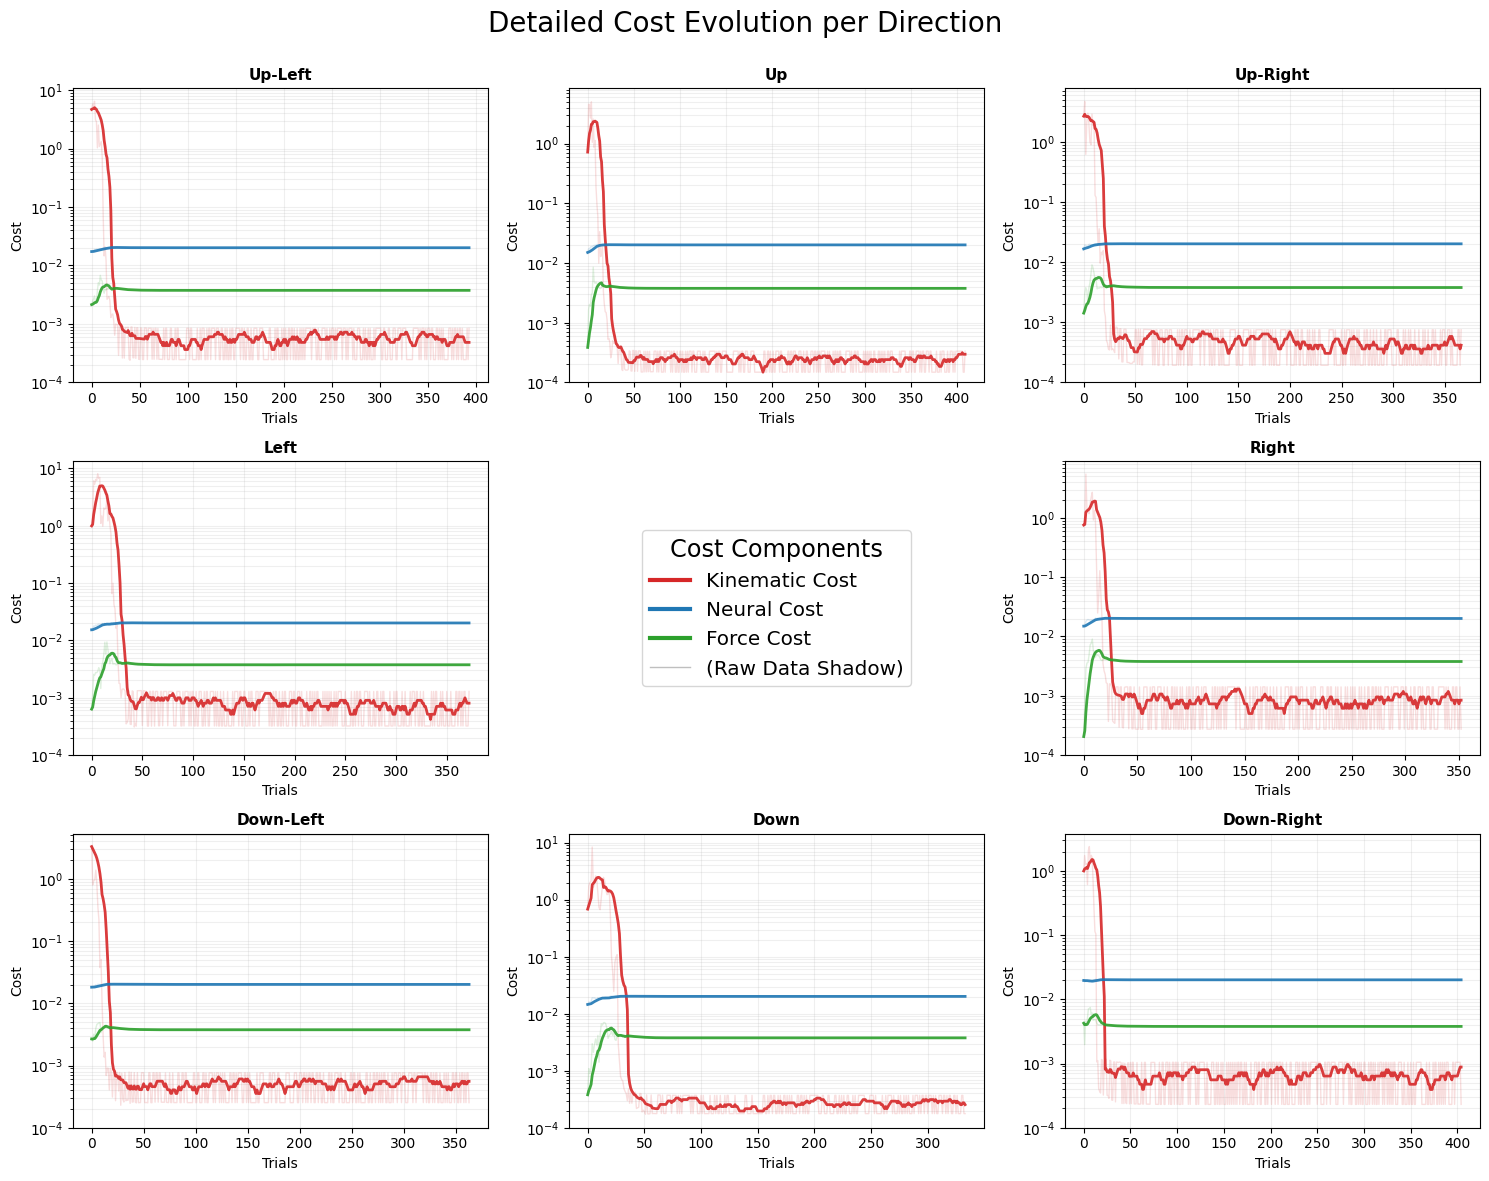

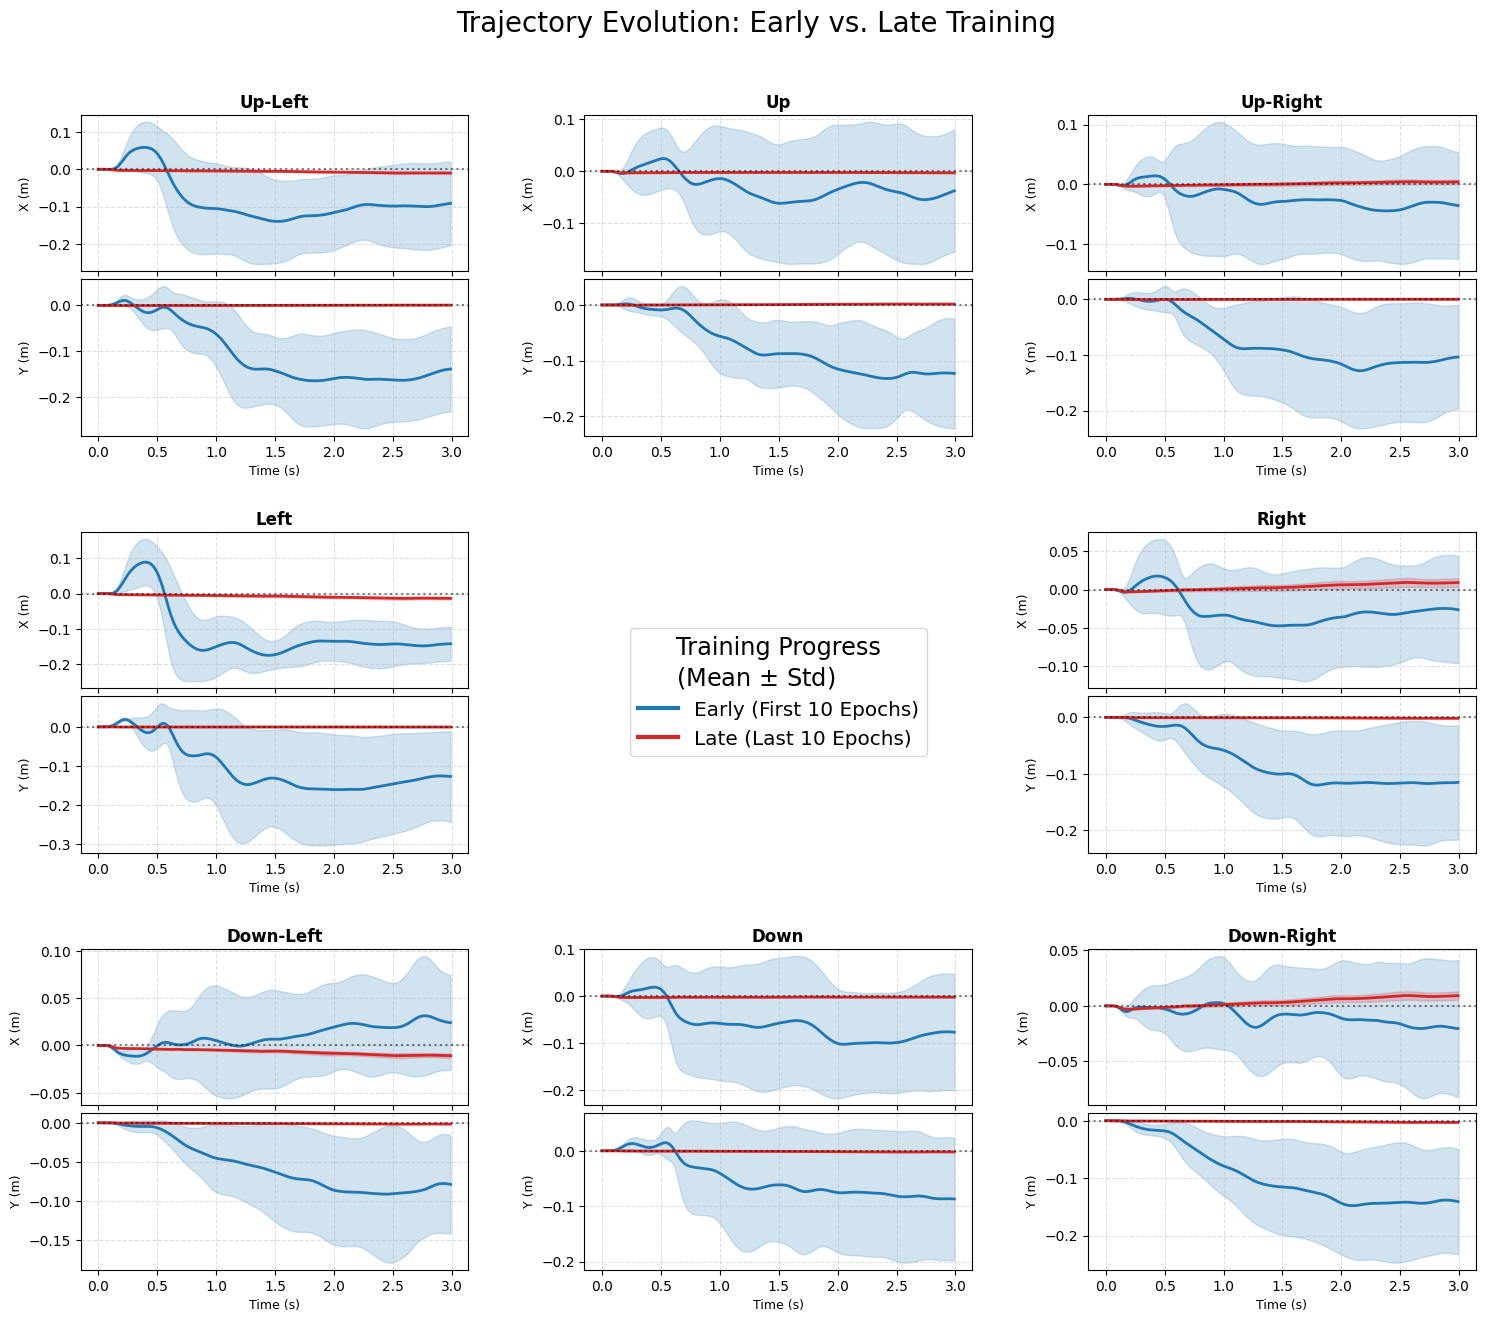

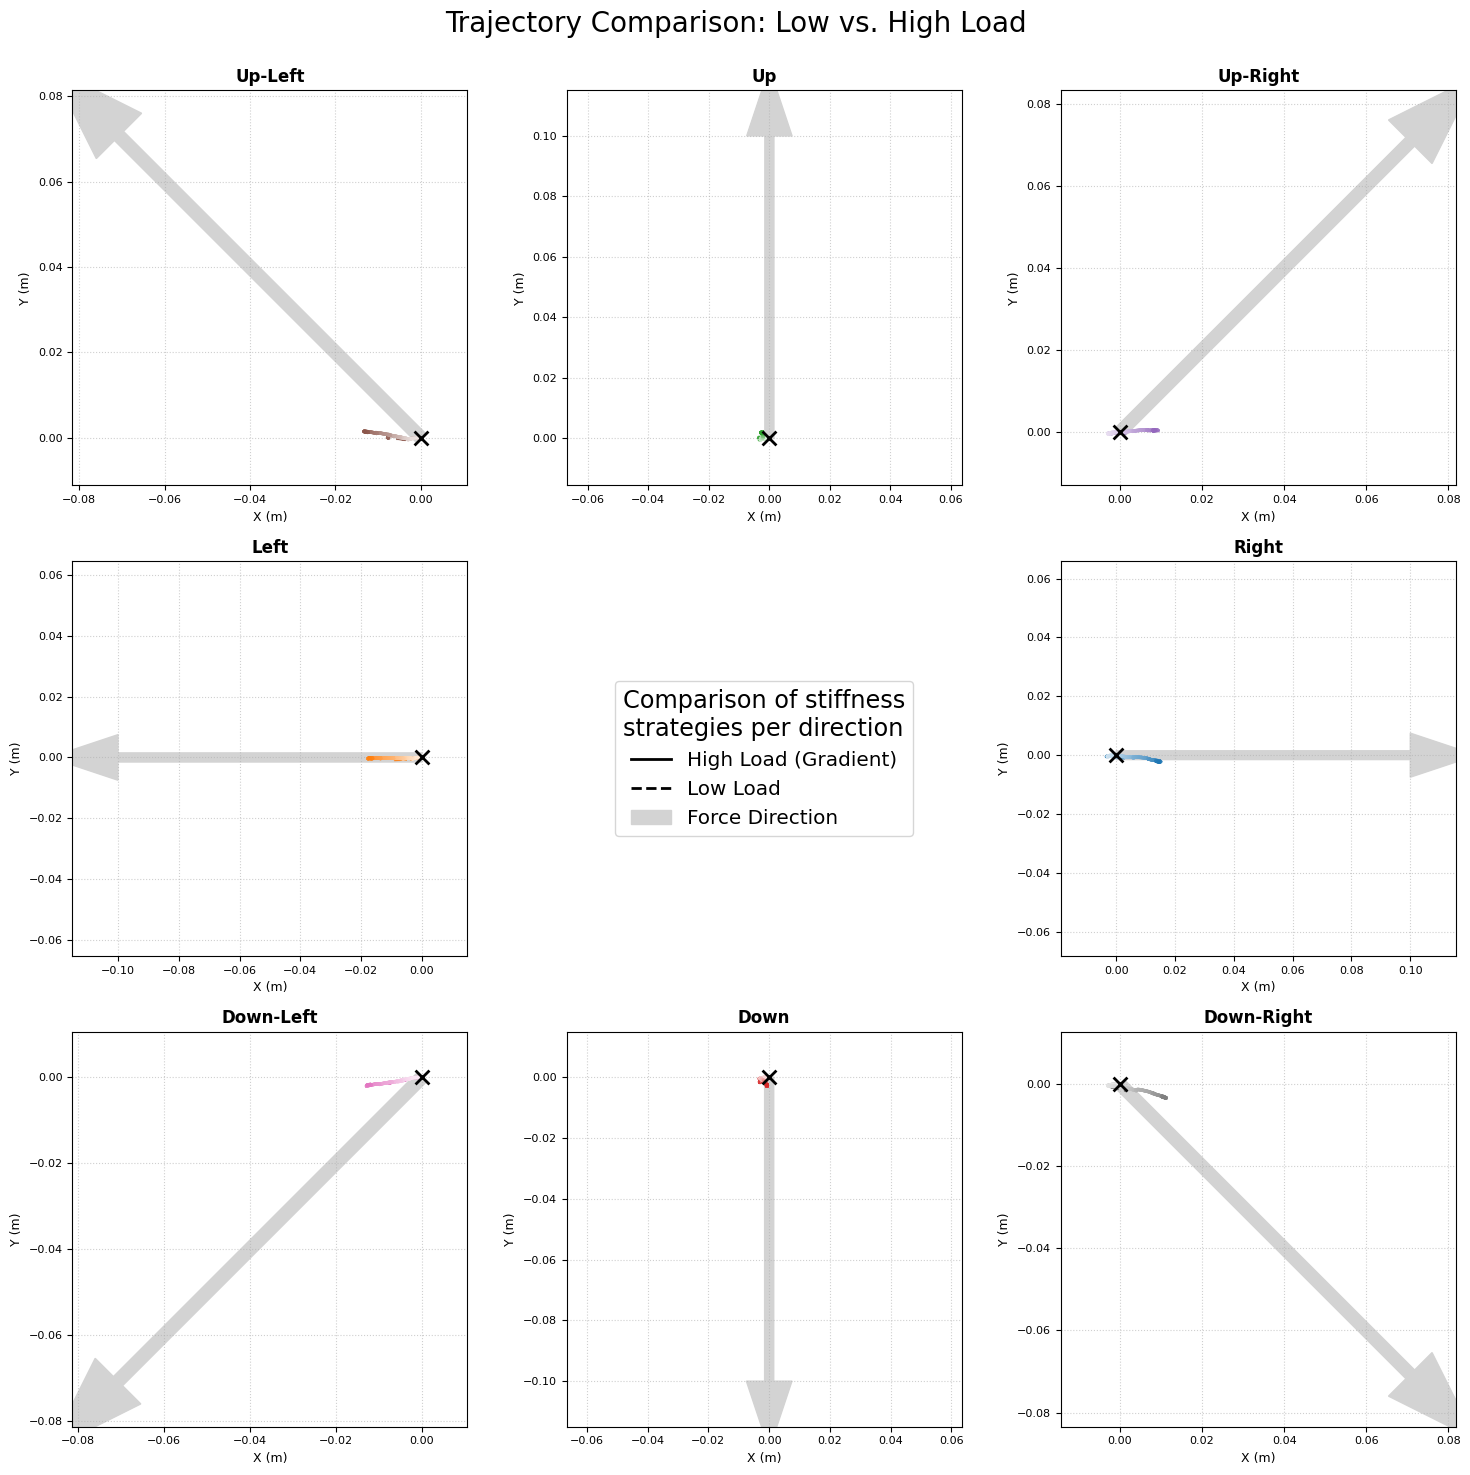

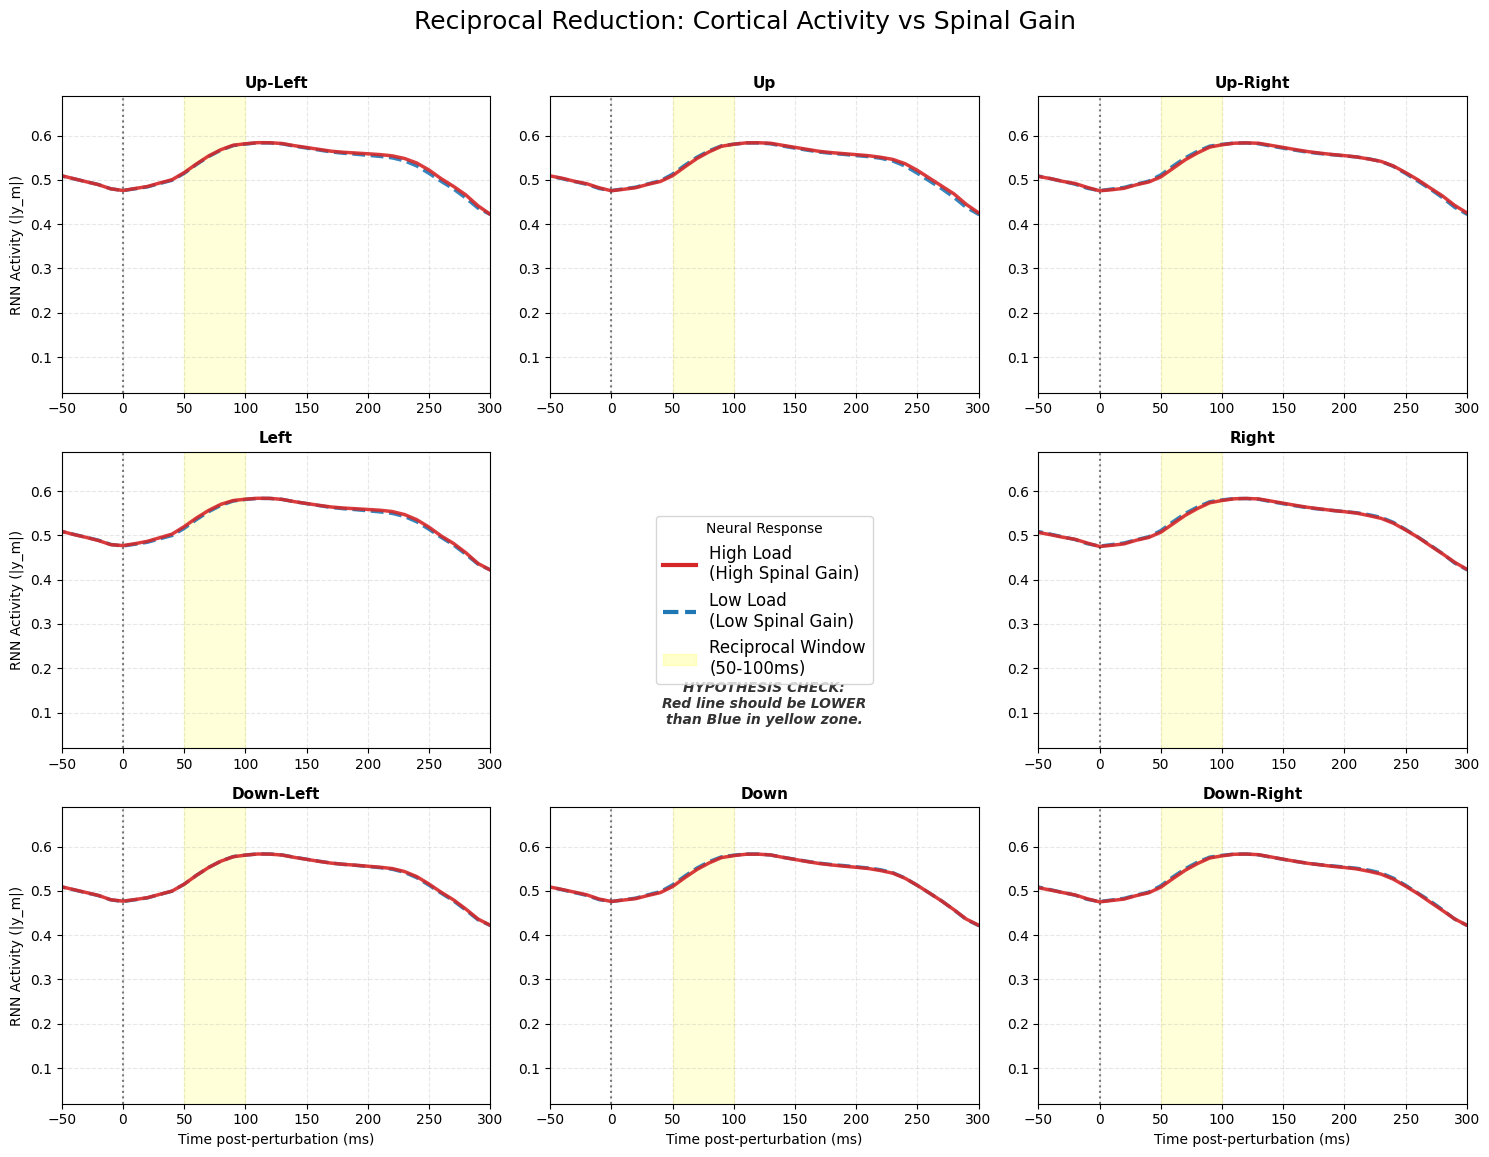

In [169]:
plot_detailed_cost_history(target_results)
plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata)
plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions)
plot_neural_activity_comparison(epoch_metadata, epoch_neural_activity, Tp_step)

---

# Biomechanical Control Under Perturbation - Analysis of Results

This simulation trained a neural controller to stabilize a two-link musculoskeletal arm against unexpected external loads. The results demonstrate the emergence of a biologically plausible **impedance control** strategy, characterized by a distinct trade-off between stiffness and energy efficiency.

### 1. The "Yield-and-Stabilize" Strategy (Damped Drift)

The gradient trajectories (solid lines in the grid plot) reveal that the arm does not rigidly hold its position, nor does it snap back to the center after being hit. Instead, it exhibits a controlled yielding behavior.

* **Mechanism:** The perturbation is applied as a step force. The arm's intrinsic stiffness is insufficient to resist this load instantly ($F_{ext} > K \cdot \Delta x$).
* **The Drift:** Initially, the arm drifts rapidly away from the center along the direction of the force (the light-colored start of the line).
* **The Stabilization:** As the neural controller reacts and muscle tension builds, the arm decelerates and settles into a new equilibrium point (the dark end of the line).
* **Result:** Rather than a "hook" shape (drift and return), we observe a **damped drift**. The controller effectively acts as a brake, preventing the arm from flailing wildly but stopping short of pulling it all the way back.

### 2. Evolution of Competence (Early vs. Late)

The **Trajectory Evolution (Mean $\pm$ Std)** plots reveal how the policy matures over training.

* **Early Epochs (Blue):** The agent exhibits high variability (wide shaded regions) and large excursions. The arm often continues to drift significantly further, indicating a lack of effective stiffness.
* **Late Epochs (Red):** The variance bands tighten dramatically. The agent has learned a consistent, repeatable strategy to "catch" the weight. The trajectories are shorter and strictly bounded, confirming that the **Kinematic Cost** reduction seen in the cost plots corresponds to a real-world improvement in stability.

### 3. The Accuracy-Effort Trade-off (Steady-State Error)

A critical observation from the final plots is that the arm exhibits **Steady-State Error**—it settles away from the target $(0,0)$ at the end of the trial.

* **The "Lazy" Agent Hypothesis:** The loss function penalizes both **Position Error** (Kinematic Cost) and **Muscle Effort** (Neural/Force Cost).
* **The Equilibrium:** To pull the arm back to $(0,0)$ against a high load requires massive, continuous muscle activation. The agent has learned that it is "cheaper" to let the arm drift to a point where the **passive elastic tension** of the stretched muscles helps balance the load.
* **Interpretation:** The agent prioritizes **energy efficiency** over **perfect accuracy**. It minimizes the drift enough to prevent failure (extreme error) but avoids the high metabolic cost required for perfect correction.

### 4. Biomechanical Asymmetry

The plots reveal that the arm does not handle all directions equally, reflecting the underlying geometry of the musculoskeletal model.

* **Up-Left vs. Up-Right:** The "Up-Left" trajectory is noticeably tighter than "Up-Right." This is likely due to the **Moment Arm Matrix ($M_m$)** at the posture $\theta_s=35^\circ, \theta_e=90^\circ$. Flexion mechanics are generally more mechanically advantageous in this workspace, whereas extending against a load (Up-Right) involves complex synergies that result in larger displacements.

### 5. Conclusion

The trained policy successfully solves the stabilization task by learning a robust **Impedance Control** law. It transitions from a "floppy" initial state to a "stiff" controller that acts as a damper. The residual steady-state error highlights a biological reality: the motor system optimizes for a compromise between task performance (error) and metabolic cost (effort), rather than absolute kinematic perfection.